<a href="https://colab.research.google.com/github/Prathiksha-66/Traffic_Management_System_ML/blob/main/Traffic_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/traffic.csv')
print(df)

                  DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]


In [ ]:
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
df.shape

(48120, 4)

In [ ]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB


In [ ]:
df['Hour'] = df['DateTime'].dt.hour

In [ ]:
df[['DateTime', 'Hour']].head(10)


,DateTime,Hour
0,2015-11-01 00:00:00,0
1,2015-11-01 01:00:00,1
2,2015-11-01 02:00:00,2
3,2015-11-01 03:00:00,3
4,2015-11-01 04:00:00,4
5,2015-11-01 05:00:00,5
6,2015-11-01 06:00:00,6
7,2015-11-01 07:00:00,7
8,2015-11-01 08:00:00,8
9,2015-11-01 09:00:00,9


In [ ]:
df['Day'] = df['DateTime'].dt.day

In [ ]:
df['Month'] = df['DateTime'].dt.month

In [ ]:
df['Year'] = df['DateTime'].dt.year

In [ ]:
df['Weekday'] = df['DateTime'].dt.weekday

In [ ]:
df[['DateTime', 'Junction', 'Vehicles', 'Hour', 'Day', 'Month', 'Year', 'Weekday']].head(10)

,DateTime,Junction,Vehicles,Hour,Day,Month,Year,Weekday
0,2015-11-01 00:00:00,1,15,0,1,11,2015,6
1,2015-11-01 01:00:00,1,13,1,1,11,2015,6
2,2015-11-01 02:00:00,1,10,2,1,11,2015,6
3,2015-11-01 03:00:00,1,7,3,1,11,2015,6
4,2015-11-01 04:00:00,1,9,4,1,11,2015,6
5,2015-11-01 05:00:00,1,6,5,1,11,2015,6
6,2015-11-01 06:00:00,1,9,6,1,11,2015,6
7,2015-11-01 07:00:00,1,8,7,1,11,2015,6
8,2015-11-01 08:00:00,1,11,8,1,11,2015,6
9,2015-11-01 09:00:00,1,12,9,1,11,2015,6


In [ ]:
junction_traffic = df.groupby('Junction')['Vehicles'].mean()

print(junction_traffic)

Junction
1    45.052906
2    14.253221
3    13.694010
4     7.251611
Name: Vehicles, dtype: float64


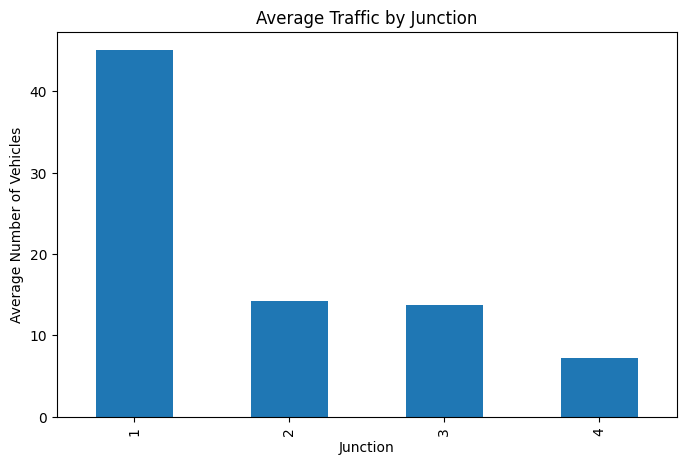

In [ ]:
plt.figure(figsize=(8, 5))

junction_traffic.plot(kind='bar')

plt.xlabel('Junction')
plt.ylabel('Average Number of Vehicles')
plt.title('Average Traffic by Junction')

plt.show()

In [ ]:
hourly_traffic = df.groupby('Hour')['Vehicles'].mean()

print(hourly_traffic)

Hour
0     23.540648
1     19.654863
2     17.102743
3     14.847382
4     12.973067
5     12.173566
6     12.980050
7     14.703242
8     16.402993
9     19.379551
10    24.229925
11    27.495262
12    28.403990
13    25.588529
14    27.702743
15    27.650374
16    26.674314
17    26.648379
18    28.095262
19    29.854863
20    29.824938
21    28.202993
22    27.226933
23    25.635411
Name: Vehicles, dtype: float64


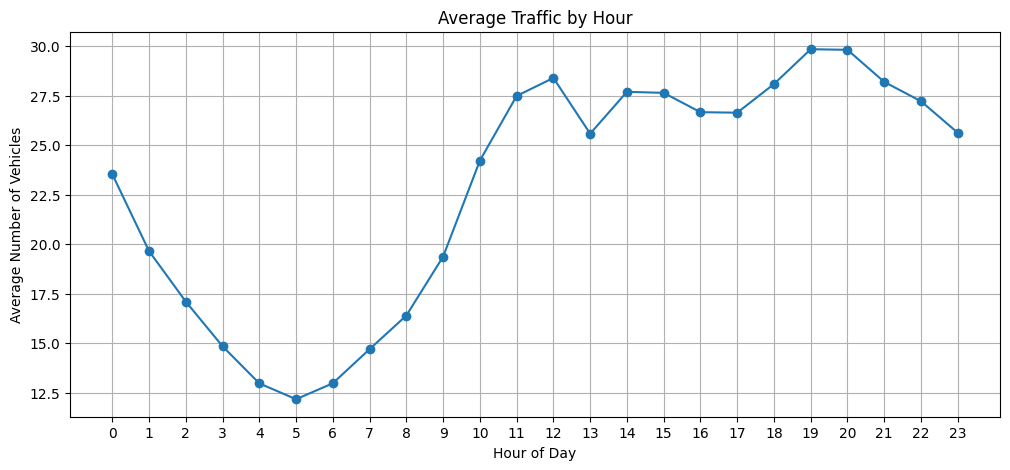

In [ ]:
plt.figure(figsize=(12, 5))

hourly_traffic.plot(kind='line', marker='o')

plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Vehicles')
plt.title('Average Traffic by Hour')

plt.xticks(range(0, 24))

plt.grid()

plt.show()

In [ ]:
busiest_hour = hourly_traffic.idxmax()
max_traffic = hourly_traffic.max()

print("Busiest Hour:", busiest_hour)
print("Average Vehicles:", round(max_traffic, 2))

Busiest Hour: 19
Average Vehicles: 29.85


In [ ]:
least_busy_hour = hourly_traffic.idxmin()
min_traffic = hourly_traffic.min()

print("Least Busy Hour:", least_busy_hour)
print("Average Vehicles:", round(min_traffic, 2))

Least Busy Hour: 5
Average Vehicles: 12.17


In [ ]:
weekday_traffic = df.groupby('Weekday')['Vehicles'].mean()

print(weekday_traffic)

Weekday
0    24.409408
1    25.286731
2    25.149681
3    25.152875
4    23.802120
5    18.544611
6    17.134727
Name: Vehicles, dtype: float64


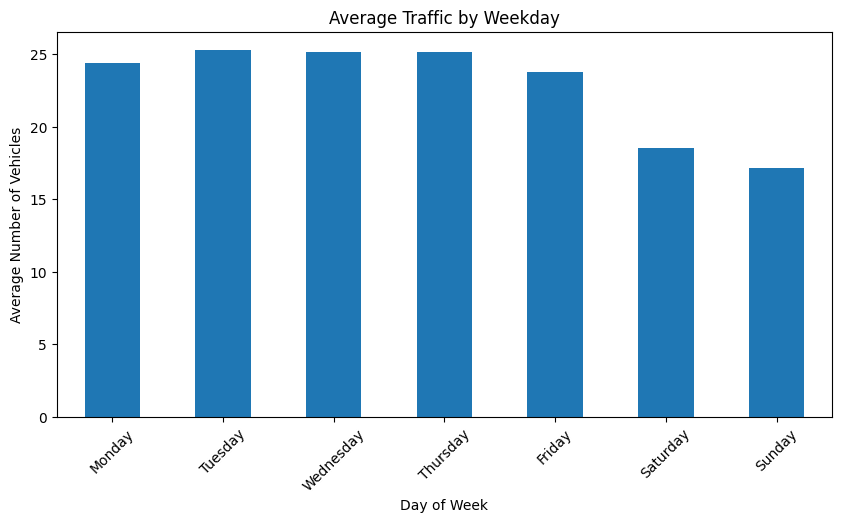

In [ ]:
plt.figure(figsize=(10, 5))

weekday_traffic.plot(kind='bar')

plt.xlabel('Day of Week')
plt.ylabel('Average Number of Vehicles')
plt.title('Average Traffic by Weekday')

plt.xticks(
    ticks=range(7),
    labels=['Monday', 'Tuesday', 'Wednesday',
            'Thursday', 'Friday', 'Saturday', 'Sunday'],
    rotation=45
)

plt.show()

In [ ]:
df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)


In [ ]:
df['Lag_1'] = df.groupby('Junction')['Vehicles'].shift(1)

In [ ]:
df['Lag_24'] = df.groupby('Junction')['Vehicles'].shift(24)

In [ ]:
df['Rolling_Mean_3'] = (
    df.groupby('Junction')['Vehicles']
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

In [ ]:
df[['DateTime', 'Junction', 'Vehicles',
    'Lag_1', 'Lag_24', 'Rolling_Mean_3']].head(30)

,DateTime,Junction,Vehicles,Lag_1,Lag_24,Rolling_Mean_3
0,2015-11-01 00:00:00,1,15,NaN,NaN,NaN
1,2015-11-01 01:00:00,1,13,15.0,NaN,NaN
2,2015-11-01 02:00:00,1,10,13.0,NaN,NaN
3,2015-11-01 03:00:00,1,7,10.0,NaN,12.666667
4,2015-11-01 04:00:00,1,9,7.0,NaN,10.000000
5,2015-11-01 05:00:00,1,6,9.0,NaN,8.666667
6,2015-11-01 06:00:00,1,9,6.0,NaN,7.333333
7,2015-11-01 07:00:00,1,8,9.0,NaN,8.000000
8,2015-11-01 08:00:00,1,11,8.0,NaN,7.666667
9,2015-11-01 09:00:00,1,12,11.0,NaN,9.333333


In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0
Hour,0
Day,0
Month,0
Year,0
Weekday,0
Lag_1,0


In [ ]:
features = [
    'Junction',
    'Hour',
    'Day',
    'Month',
    'Year',
    'Weekday',
    'Lag_1',
    'Lag_24',
    'Rolling_Mean_3'
]

In [ ]:
target = 'Vehicles'

In [ ]:
X = df[features]
y = df[target]

In [ ]:
X.head()

,Junction,Hour,Day,Month,Year,Weekday,Lag_1,Lag_24,Rolling_Mean_3
0,1,0,2,11,2015,0,15.0,15.0,18.000000
1,1,1,2,11,2015,0,14.0,13.0,16.333333
2,1,2,2,11,2015,0,12.0,10.0,13.666667
3,1,3,2,11,2015,0,14.0,7.0,13.333333
4,1,4,2,11,2015,0,12.0,9.0,12.666667


In [ ]:
y.head()

,Vehicles
0,14
1,12
2,14
3,12
4,12


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
training_data = X_train.copy()
training_data['y_train'] = y_train.values

In [ ]:
testing_data = X_test.copy()
testing_data['y_test'] = y_test.values

In [ ]:
print("Training Data:")
display(training_data.head())

Training Data:


,Junction,Hour,Day,Month,Year,Weekday,Lag_1,Lag_24,Rolling_Mean_3,y_train
33051,3,3,13,4,2016,2,9.0,7.0,15.333333,7
8957,1,5,9,11,2016,2,36.0,38.0,42.666667,31
16510,2,22,21,1,2016,3,12.0,12.0,11.333333,12
12640,1,16,11,4,2017,1,93.0,96.0,97.666667,91
28777,2,1,16,6,2017,4,31.0,29.0,32.000000,25


In [ ]:
print("Testing Data:")
display(testing_data.head())


Testing Data:


,Junction,Hour,Day,Month,Year,Weekday,Lag_1,Lag_24,Rolling_Mean_3,y_test
17378,2,2,27,2,2016,5,8.0,10.0,10.333333,6
26945,2,17,31,3,2017,4,29.0,31.0,29.333333,31
36989,3,5,24,9,2016,5,10.0,8.0,13.666667,8
47143,4,7,25,5,2017,3,6.0,4.0,4.000000,3
21417,2,9,13,8,2016,5,7.0,11.0,6.666667,9


In [ ]:
print("Training Data Shape:", training_data.shape)
print("Testing Data Shape:", testing_data.shape)

Training Data Shape: (38419, 10)
Testing Data Shape: (9605, 10)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[ 7.97 30.34  8.55  6.22  7.77 13.22  5.3  22.94 15.86 10.66]


In [ ]:
print("Actual Values:")
print(y_test.values[:10])

Actual Values:
[ 6 31  8  3  9 11  2 22 19 11]


In [ ]:
results = pd.DataFrame()

results['Actual_Vehicles'] = y_test.values
results['Predicted_Vehicles'] = y_pred

results.head(20)

,Actual_Vehicles,Predicted_Vehicles
0,6,7.97
1,31,30.34
2,8,8.55
3,3,6.22
4,9,7.77
5,11,13.22
6,2,5.30
7,22,22.94
8,19,15.86
9,11,10.66


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.405881311816762


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 3.670984105092779


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9680113581530624


In [ ]:
print("Model Evaluation")
print("---------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

Model Evaluation
---------------------------
MAE  : 2.405881311816762
RMSE : 3.670984105092779
R2   : 0.9680113581530624


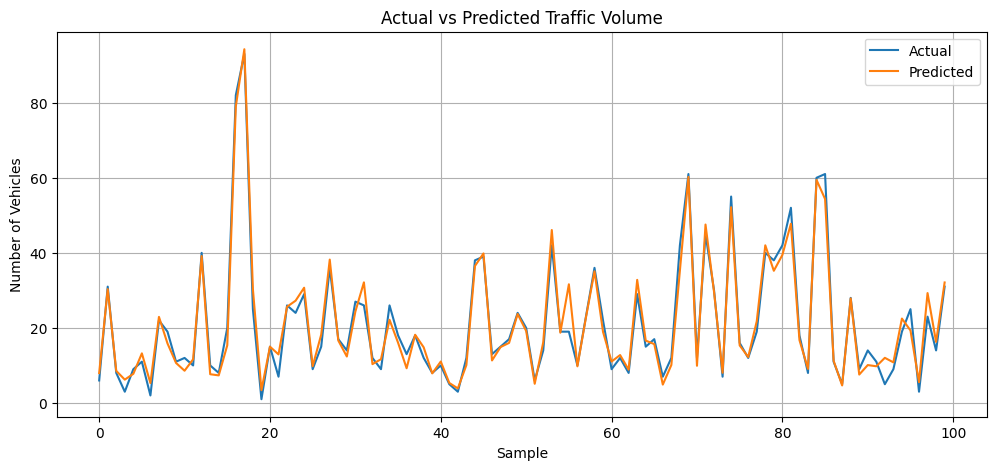

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    y_pred[:100],
    label='Predicted'
)

plt.xlabel('Sample')
plt.ylabel('Number of Vehicles')
plt.title('Actual vs Predicted Traffic Volume')
plt.legend()
plt.grid()

plt.show()

In [ ]:
feature_importance = pd.DataFrame()

feature_importance['Feature'] = X_train.columns
feature_importance['Importance'] = model.feature_importances_

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,Lag_1,0.940651
1,Hour,0.015233
7,Lag_24,0.014955
8,Rolling_Mean_3,0.012003
2,Day,0.005378
5,Weekday,0.004510
3,Month,0.004125
0,Junction,0.002148
4,Year,0.000997


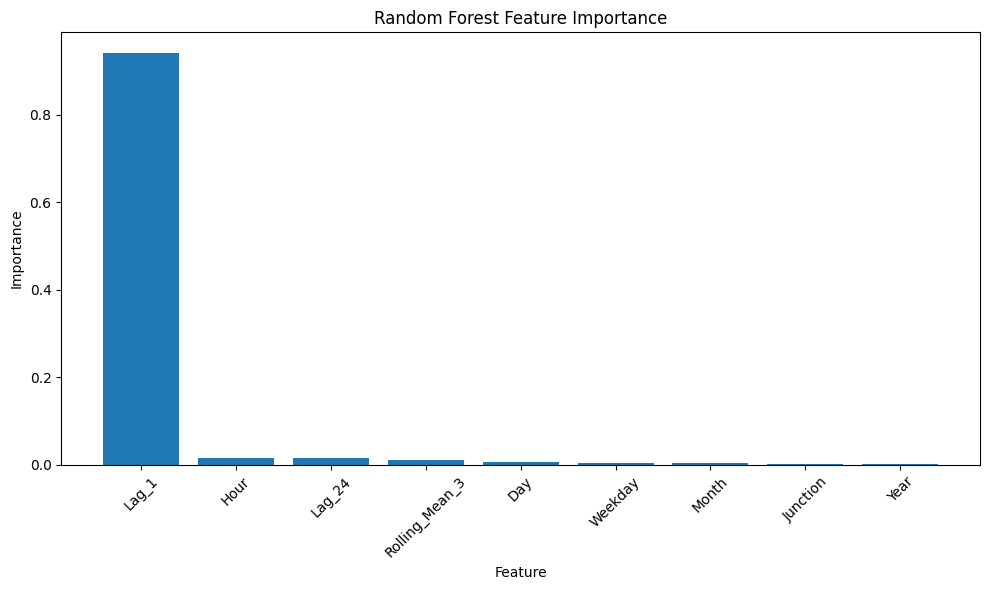

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
new_data = pd.DataFrame({
    'Junction': [1],
    'Hour': [19],
    'Day': [15],
    'Month': [6],
    'Year': [2017],
    'Weekday': [3],
    'Lag_1': [40],
    'Lag_24': [38],
    'Rolling_Mean_3': [39]
})

In [ ]:
predicted_vehicles = model.predict(new_data)
print("Predicted Vehicles:", predicted_vehicles[0])

Predicted Vehicles: 39.7


In [ ]:
print(df['Vehicles'].describe())

count    48024.000000
mean        22.822547
std         20.757982
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64


In [ ]:
def traffic_recommendation(level):
    if level == "Low":
        return "Maintain normal signal timing"
    elif level == "Medium":
        return "Increase green-light duration moderately"
    else:
        return "Increase green-light duration and prioritize this junction"

In [ ]:
print("Minimum vehicles:", df['Vehicles'].min())
print("Maximum vehicles:", df['Vehicles'].max())
print("Mean vehicles:", df['Vehicles'].mean())
print("Median vehicles:", df['Vehicles'].median())

Minimum vehicles: 1
Maximum vehicles: 180
Mean vehicles: 22.82254705980343
Median vehicles: 15.0


In [ ]:
low_threshold = df['Vehicles'].quantile(0.33)
high_threshold = df['Vehicles'].quantile(0.67)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 11.0
High threshold: 23.0


In [ ]:
def traffic_level(vehicles):

    if vehicles <= low_threshold:
        return "Low"

    elif vehicles <= high_threshold:
        return "Medium"

    else:
        return "High"

In [ ]:
print(traffic_level(5))
print(traffic_level(20))
print(traffic_level(50))

Low
Medium
High


In [ ]:
df['Traffic_Level'] = df['Vehicles'].apply(traffic_level)

In [ ]:
df[['Vehicles', 'Traffic_Level']].head(20)

,Vehicles,Traffic_Level
0,14,Medium
1,12,Medium
2,14,Medium
3,12,Medium
4,12,Medium
5,11,Low
6,13,Medium
7,14,Medium
8,12,Medium
9,22,Medium


In [ ]:
print(df['Traffic_Level'].value_counts())

Traffic_Level
Low       17617
High      15325
Medium    15082
Name: count, dtype: int64


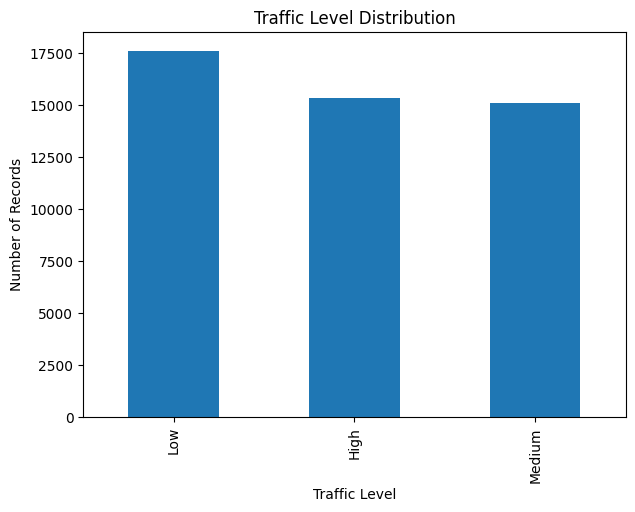

In [ ]:
plt.figure(figsize=(7,5))

df['Traffic_Level'].value_counts().plot(kind='bar')

plt.xlabel('Traffic Level')
plt.ylabel('Number of Records')
plt.title('Traffic Level Distribution')

plt.show()

In [ ]:
predicted_levels = [
    traffic_level(value)
    for value in y_pred
]

In [ ]:
prediction_results = pd.DataFrame()

prediction_results['Actual_Vehicles'] = y_test.values
prediction_results['Predicted_Vehicles'] = y_pred
prediction_results['Predicted_Traffic_Level'] = predicted_levels

prediction_results.head(20)

,Actual_Vehicles,Predicted_Vehicles,Predicted_Traffic_Level
0,6,7.97,Low
1,31,30.34,High
2,8,8.55,Low
3,3,6.22,Low
4,9,7.77,Low
5,11,13.22,Medium
6,2,5.30,Low
7,22,22.94,Medium
8,19,15.86,Medium
9,11,10.66,Low


In [ ]:
def traffic_recommendation(level):

    if level == "Low":
        return "Normal signal timing"

    elif level == "Medium":
        return "Increase green-light duration moderately"

    else:
        return "Increase green-light duration and prioritize the junction"

In [ ]:
print(traffic_recommendation("Low"))
print(traffic_recommendation("Medium"))
print(traffic_recommendation("High"))

Normal signal timing
Increase green-light duration moderately
Increase green-light duration and prioritize the junction


In [ ]:
def predict_traffic(input_data):

    predicted_vehicles = model.predict(input_data)[0]

    level = traffic_level(predicted_vehicles)

    recommendation = traffic_recommendation(level)

    print("Predicted Vehicles:", round(predicted_vehicles, 2))
    print("Traffic Level:", level)
    print("Recommendation:", recommendation)

In [ ]:
new_data = pd.DataFrame({
    'Junction': [1],
    'Hour': [19],
    'Day': [15],
    'Month': [6],
    'Year': [2017],
    'Weekday': [3],
    'Lag_1': [40],
    'Lag_24': [38],
    'Rolling_Mean_3': [39]
})

In [ ]:
predict_traffic(new_data)

Predicted Vehicles: 39.7
Traffic Level: High
Recommendation: Increase green-light duration and prioritize the junction


In [ ]:
low_threshold = df['Vehicles'].quantile(0.33)
high_threshold = df['Vehicles'].quantile(0.67)

print("Low threshold :", round(low_threshold, 2))
print("High threshold:", round(high_threshold, 2))

Low threshold : 11.0
High threshold: 23.0


In [ ]:
def traffic_level(vehicles):
    if vehicles <= low_threshold:
        return "Low"
    elif vehicles <= high_threshold:
        return "Medium"
    else:
        return "High"

In [ ]:

def traffic_recommendation(level):

    if level == "Low":
        return "Normal signal timing"

    elif level == "Medium":
        return "Moderately increase green-light duration"

    else:
        return "Increase green-light duration and prioritize this junction"

In [ ]:
def traffic_management_prediction(input_data):

    predicted_vehicles = model.predict(input_data)[0]

    level = traffic_level(predicted_vehicles)

    recommendation = traffic_recommendation(level)

    print("===================================")
    print("      TRAFFIC MANAGEMENT SYSTEM")
    print("===================================")
    print("Predicted Vehicles :", round(predicted_vehicles, 2))
    print("Traffic Level      :", level)
    print("Recommendation     :", recommendation)
    print("===================================")

In [ ]:
new_data = pd.DataFrame({
    'Junction': [1],
    'Hour': [19],
    'Day': [15],
    'Month': [6],
    'Year': [2017],
    'Weekday': [3],
    'Lag_1': [40],
    'Lag_24': [38],
    'Rolling_Mean_3': [39]
})

In [ ]:
traffic_management_prediction(new_data)

      TRAFFIC MANAGEMENT SYSTEM
Predicted Vehicles : 39.7
Traffic Level      : High
Recommendation     : Increase green-light duration and prioritize this junction


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html>
<head>
    <title>Traffic Management System</title>

    <style>
        body {
            background: #07111f;
            color: white;
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 30px;
        }

        .container {
            max-width: 1250px;
            margin: auto;
        }

        h1 {
            color: #00c6ff;
        }

        .card {
            background: #0e1b2d;
            padding: 25px;
            border-radius: 20px;
            margin-top: 20px;
        }

        input,
        select {
            width: 100%;
            padding: 12px;
            margin-top: 8px;
            margin-bottom: 15px;
            background: #0a1829;
            color: white;
            border: 1px solid #29415f;
            border-radius: 8px;
        }

        button {
            width: 100%;
            padding: 14px;
            background: #0072ff;
            color: white;
            border: none;
            border-radius: 8px;
            font-size: 16px;
            cursor: pointer;
        }

        button:hover {
            background: #005dcc;
        }

        .result {
            margin-top: 20px;
            padding: 20px;
            background: #13263d;
            border-radius: 15px;
        }

        .value {
            font-size: 40px;
            font-weight: bold;
            color: #00c6ff;
        }
    </style>
</head>

<body>

<div class="container">

    <h1>🚦 Traffic Management System</h1>
    <p>Machine Learning Based Traffic Prediction</p>

    <div class="card">

        <h2>Traffic Prediction</h2>

        <label>Junction</label>
        <select id="junction">
            <option value="1">Junction 1</option>
            <option value="2">Junction 2</option>
            <option value="3">Junction 3</option>
            <option value="4">Junction 4</option>
        </select>

        <label>Hour</label>
        <input type="number" id="hour" min="0" max="23" placeholder="Example: 19">

        <label>Day</label>
        <input type="number" id="day" min="1" max="31" placeholder="Example: 15">

        <label>Month</label>
        <input type="number" id="month" min="1" max="12" placeholder="Example: 6">

        <label>Year</label>
        <input type="number" id="year" placeholder="Example: 2017">

        <label>Weekday</label>
        <select id="weekday">
            <option value="0">Monday</option>
            <option value="1">Tuesday</option>
            <option value="2">Wednesday</option>
            <option value="3">Thursday</option>
            <option value="4">Friday</option>
            <option value="5">Saturday</option>
            <option value="6">Sunday</option>
        </select>

        <label>Previous Hour Vehicles</label>
        <input type="number" id="lag1" placeholder="Example: 40">

        <label>Previous Day Vehicles</label>
        <input type="number" id="lag24" placeholder="Example: 38">

        <label>3-Hour Average Vehicles</label>
        <input type="number" id="rolling" placeholder="Example: 39">

        <button onclick="predictTraffic()">
            🚀 Predict Traffic
        </button>

        <div class="result">

            <h3>Prediction Result</h3>

            <div class="value" id="vehicleResult">
                --
            </div>

            <p id="trafficLevel">
                Traffic Level: --
            </p>

            <p id="recommendation">
                Recommendation: --
            </p>

        </div>

    </div>

</div>


<script>

function predictTraffic() {

    let junction =
        Number(document.getElementById("junction").value);

    let hour =
        Number(document.getElementById("hour").value);

    let lag1 =
        Number(document.getElementById("lag1").value);

    let lag24 =
        Number(document.getElementById("lag24").value);

    let rolling =
        Number(document.getElementById("rolling").value);


    /*
       TEMPORARY FRONTEND DEMO

       This is NOT the trained Random Forest model.
       We will connect Flask + your .pkl model next.
    */

    let predicted =
        (lag1 * 0.60) +
        (lag24 * 0.15) +
        (rolling * 0.15) +
        (hour * 0.10);


    let level;
    let recommendation;


    if (predicted <= 10) {

        level = "LOW";

        recommendation =
            "Maintain normal signal timing.";

    }

    else if (predicted <= 25) {

        level = "MEDIUM";

        recommendation =
            "Moderately increase green-light duration.";

    }

    else {

        level = "HIGH";

        recommendation =
            "Increase green-light duration and prioritize this junction.";

    }


    document.getElementById("vehicleResult").innerText =
        predicted.toFixed(2) + " Vehicles";

    document.getElementById("trafficLevel").innerText =
        "Traffic Level: " + level;

    document.getElementById("recommendation").innerText =
        "Recommendation: " + recommendation;

}

</script>

</body>
</html>

Overwriting index.html


In [ ]:
import os
print(os.path.exists("index.html"))

True


In [ ]:
!pip install flask -q


In [ ]:
from flask import Flask, send_file
from google.colab import output
import threading

app = Flask(__name__)

@app.route("/")
def home():
    return send_file("index.html")

def run_flask():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [ ]:
output.serve_kernel_port_as_window(5000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
from flask import Flask, send_file
import threading

app = Flask(__name__)

@app.route("/")
def home():
    return send_file("index.html")

def run_app():
    app.run(host="0.0.0.0", port=5000)

thread = threading.Thread(target=run_app)
thread.start()